<a href="https://colab.research.google.com/github/yaser2532/python-basics-/blob/main/EDA_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔄 Connecting to your Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📖 Reading file from: /content/drive/MyDrive/Colab Notebooks/Titanic Dataset.xlsx
✅ Dataset loaded successfully!
Dataset shape: 712 rows, 7 columns


================ MODEL EVALUATION ================
Accuracy Score: 76.2238%

Classification Report:
              precision    recall  f1-score   support

          No       0.77      0.81      0.79        80
         Yes       0.75      0.70      0.72        63

    accuracy                           0.76       143
   macro avg       0.76      0.76      0.76       143
weighted avg       0.76      0.76      0.76       143


🎨 Rendering evaluation visual matrices...


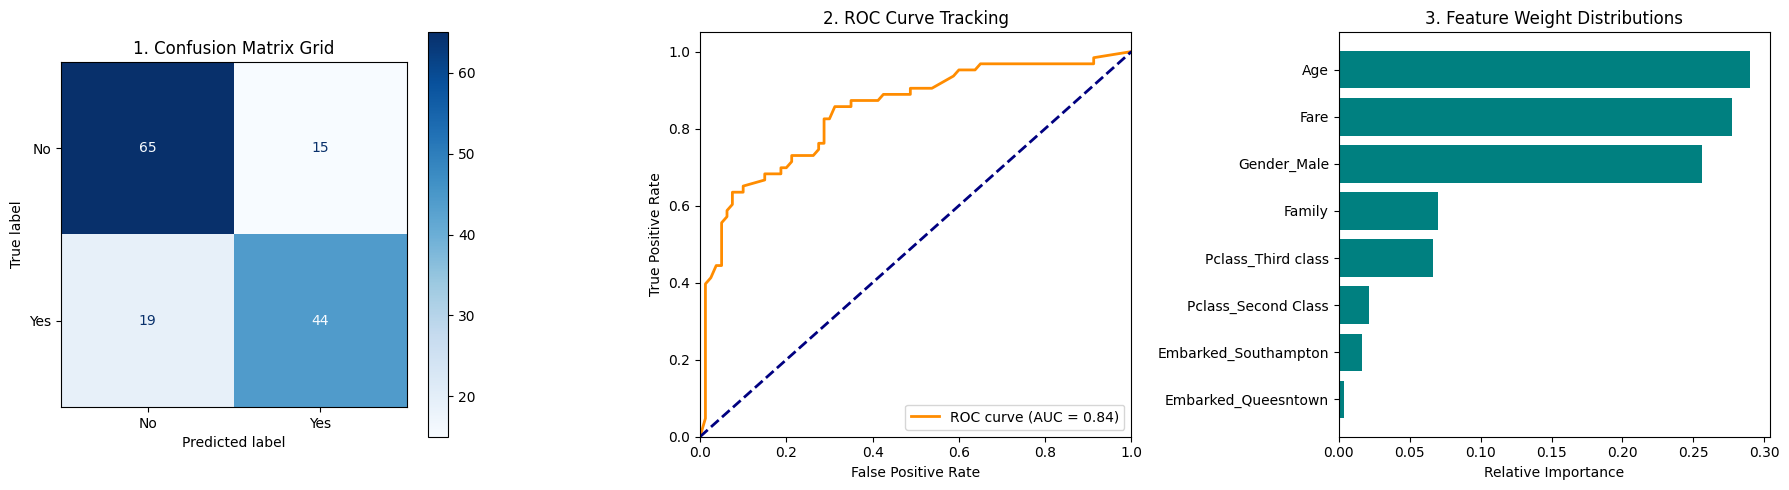

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# --- STEP 1: MOUNT GOOGLE DRIVE ---
print("🔄 Connecting to your Google Drive...")
drive.mount('/content/drive')

# --- STEP 2: LOAD DATA VIA DIRECT PATH ---
path = "/content/drive/MyDrive/Colab Notebooks/Titanic Dataset.xlsx"
print(f"📖 Reading file from: {path}")

# Reading the Excel file directly using your exact configuration
df = pd.read_excel(path)

print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# --- STEP 3: PREPROCESSING & ENCODING ---
# Encode the 'Survived' text targets ('No'/'Yes') to binary values (0/1)
le = LabelEncoder()
df['Survived'] = le.fit_transform(df['Survived'])

# Establish independent features (X) and target variable (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

# Grouping text vs numerical columns for automated transformations
categorical_features = ['Pclass', 'Gender', 'Embarked']
numerical_features = ['Age', 'Family', 'Fare']

# Preprocessing transformer pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# --- STEP 4: TRAIN-TEST SPLIT ---
# Splitting dataset: 80% for training parameters, 20% for performance testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 5: MODEL PIPELINE DESIGN & TRAINING ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training the classifier model
rf_pipeline.fit(X_train, y_train)

# --- STEP 6: MODEL PREDICTIONS & MEASUREMENTS ---
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("\n================ MODEL EVALUATION ================")
print(f"Accuracy Score: {accuracy:.4%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- STEP 7: EVALUATION GRAPH VISUALIZATIONS ---
print("\n🎨 Rendering evaluation visual matrices...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix Grid
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("1. Confusion Matrix Grid")

# Plot 2: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('2. ROC Curve Tracking')
axes[1].legend(loc="lower right")

# Plot 3: Feature Weight Importance Ranking
onehot_cols = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(onehot_cols)
importances = rf_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)

axes[2].barh(range(len(indices)), importances[indices], align='center', color='teal')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices])
axes[2].set_xlabel('Relative Importance')
axes[2].set_title('3. Feature Weight Distributions')

plt.tight_layout()
plt.show()